# Preprocesamiento de imágenes del corpus documental

Detección de imágenes duplicadas y mejora de calidad del corpus fotográfico previo a la transcripción. Combina hash exacto (MD5) y hash perceptual para identificar duplicados con diferente resolución, y aplica CLAHE para mejorar el contraste sin alterar los colores originales.

> **Nota:** este notebook es opcional. Las imágenes del corpus ya habían sido sometidas a un tratamiento técnico previo durante el escaneado, por lo que se decidió remitir las imágenes originales directamente al pipeline de transcripción. Se mantiene por reproducibilidad del proceso de exploración.

> **Requisitos:** Google Drive con la carpeta de imágenes · ver `REPRODUCIR.txt`.

## Instalación de librerías necesarias


In [1]:
!pip install opencv-python-headless Pillow numpy matplotlib scipy scikit-image --quiet

##Detección de imágenes duplicadas

Analiza la carpeta de entrada y detecta duplicados usando **dos métodos combinados**:
- **Hash exacto (MD5)** — detecta copias idénticas byte a byte
- **Hash perceptual (pHash)** — detecta imágenes visualmente iguales aunque tengan diferente compresión, tamaño o metadatos

Al finalizar muestra un informe visual y permite eliminar los duplicados de forma segura.

In [2]:
import cv2
import numpy as np
from PIL import Image, ImageEnhance, ImageFilter
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os
import glob
import shutil
from pathlib import Path
from scipy import ndimage
from skimage import exposure

In [7]:
# CONFIGURACIÓN

from google.colab import drive
drive.mount('/content/drive')

CONFIG = {
    # Directorios
    'carpeta_entrada'        : '/content/drive/MyDrive/prueba_tfm/imagenes/B_1850-1856',
    'carpeta_salida'         : 'imagenes_procesadas/',   # resultado final
    'carpeta_debug'          : 'imagenes_debug/',        # visualizaciones intermedias


}

# Crear directorios si no existen
for d in ['carpeta_entrada', 'carpeta_salida', 'carpeta_debug']:
    Path(CONFIG[d]).mkdir(parents=True, exist_ok=True)

print(' Configuración cargada.')
print(f"   Entrada : {CONFIG['carpeta_entrada']}")
print(f"   Salida  : {CONFIG['carpeta_salida']}")
print(f"   Debug   : {CONFIG['carpeta_debug']}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Configuración cargada.
   Entrada : /content/drive/MyDrive/prueba_tfm/imagenes/B_1850-1856
   Salida  : imagenes_procesadas/
   Debug   : imagenes_debug/


In [8]:
import hashlib
from collections import defaultdict
from itertools import combinations

# CONFIGURACIÓN DE DETECCIÓN

# Umbral de similitud para pHash (0 = idénticas, cuanto mayor más permisivo)
# 8: muy similar (mismo escaneo, diferente compresión)
# 15: parecidas (mismo folio, diferente encuadre o rotación leve)
UMBRAL_PHASH = 10

# Si True, mueve los duplicados a una subcarpeta en lugar de eliminarlos
MOVER_EN_VEZ_DE_ELIMINAR = True
CARPETA_DUPLICADOS = 'imagenes_duplicadas/'

def calcular_hash_md5(ruta):
    """Hash MD5 del contenido binario del archivo."""
    h = hashlib.md5()
    with open(ruta, 'rb') as f:
        for bloque in iter(lambda: f.read(65536), b''):
            h.update(bloque)
    return h.hexdigest()


def calcular_phash(ruta, hash_size=16):
    """
    Hash perceptual (pHash) de la imagen.
    Redimensiona a hash_size×hash_size en escala de grises,
    aplica DCT y codifica los coeficientes como bits.
    """
    img = cv2.imread(str(ruta), cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    # Redimensionar a tamaño fijo
    img_resized = cv2.resize(img, (hash_size * 4, hash_size * 4),
                             interpolation=cv2.INTER_AREA)
    img_float = np.float32(img_resized)
    # DCT 2D
    dct = cv2.dct(img_float)
    # Tomar el bloque de baja frecuencia hash_size×hash_size
    dct_low = dct[:hash_size, :hash_size]
    # Umbral: media de los coeficientes (sin el DC)
    media = (dct_low.sum() - dct_low[0, 0]) / (hash_size * hash_size - 1)
    # Generar hash binario
    bits = (dct_low > media).flatten()
    return bits


def distancia_hamming_phash(h1, h2):
    """Distancia de Hamming entre dos pHashes (número de bits distintos)."""
    if h1 is None or h2 is None:
        return 999
    return int(np.sum(h1 != h2))


def detectar_duplicados(carpeta, umbral_phash=10):
    """
    Analiza todas las imágenes de la carpeta y devuelve:
      - grupos_exactos : lista de listas de archivos idénticos (MD5)
      - grupos_similares : lista de listas de archivos visualmente similares (pHash)
      - info : dict con metadatos por archivo
    """
    extensiones = ['*.jpg', '*.jpeg', '*.png', '*.tif', '*.tiff', '*.bmp']
    archivos = []
    for ext in extensiones:
        archivos += glob.glob(os.path.join(carpeta, ext))
        archivos += glob.glob(os.path.join(carpeta, ext.upper()))
    archivos = sorted(set(archivos))

    if not archivos:
        print(f"No se encontraron imágenes en '{carpeta}'.")
        return [], [], {}, [] # Añadir listas vacías para pares_similares


    info = {}
    hashes_md5   = defaultdict(list)
    hashes_phash = {}

    for ruta in archivos:
        nombre = os.path.basename(ruta)
        tamano = os.path.getsize(ruta)
        img = cv2.imread(ruta)
        dims = f"{img.shape[1]}×{img.shape[0]}" if img is not None else 'N/A'

        md5   = calcular_hash_md5(ruta)
        phash = calcular_phash(ruta)

        hashes_md5[md5].append(ruta)
        hashes_phash[ruta] = phash
        info[ruta] = {'nombre': nombre, 'tamaño_kb': tamano // 1024,
                      'dims': dims, 'md5': md5}

        print(f'   ✓ {nombre:40s}  {dims:12s}  {tamano//1024:>6} KB')

    #Grupos exactos (MD5 idéntico)
    grupos_exactos = [rutas for rutas in hashes_md5.values() if len(rutas) > 1]

    #Grupos similares (pHash)
    # Excluir los que ya son exactamente idénticos
    ya_en_exactos = {r for grupo in grupos_exactos for r in grupo}
    candidatos = [r for r in archivos if r not in ya_en_exactos]

    # Union-Find para agrupar similares
    padre = {r: r for r in candidatos}

    def find(x):
        while padre[x] != x:
            padre[x] = padre[padre[x]]
            x = padre[x]
        return x

    def union(x, y):
        padre[find(x)] = find(y)

    pares_similares = []
    for r1, r2 in combinations(candidatos, 2):
        dist = distancia_hamming_phash(hashes_phash[r1], hashes_phash[r2])
        if dist <= umbral_phash:
            union(r1, r2)
            pares_similares.append((r1, r2, dist))

    # Construir grupos
    grupos_dict = defaultdict(list)
    for r in candidatos:
        grupos_dict[find(r)].append(r)
    grupos_similares = [g for g in grupos_dict.values() if len(g) > 1]

    return grupos_exactos, grupos_similares, info, pares_similares


#EJECUTAR DETECCIÓN

grupos_exactos, grupos_similares, info_archivos, pares_similares = detectar_duplicados(
    CONFIG['carpeta_entrada'], UMBRAL_PHASH
)

total_dupli = sum(len(g) - 1 for g in grupos_exactos) + \
              sum(len(g) - 1 for g in grupos_similares)

print(f'DETECCIÓN DE DUPLICADOS')
print(f'   Imágenes analizadas      : {len(info_archivos)}')
print(f'   Grupos idénticos (MD5)   : {len(grupos_exactos)}')
print(f'   Grupos similares (pHash) : {len(grupos_similares)}')
print(f'   Total posibles a eliminar: {total_dupli}')

if grupos_exactos:
    print(f'\nDUPLICADOS EXACTOS (archivos idénticos):')
    for i, grupo in enumerate(grupos_exactos, 1):
        print(f'   Grupo {i}:')
        for r in grupo:
            d = info_archivos[r]
            print(f'     • {d["nombre"]:45s} {d["dims"]:12s} {d["tamaño_kb"]:>6} KB')

if grupos_similares:
    print(f'\nDUPLICADOS SIMILARES (visualmente iguales, pHash ≤ {UMBRAL_PHASH}):')
    for i, grupo in enumerate(grupos_similares, 1):
        print(f'   Grupo {i}:')
        for r in grupo:
            d = info_archivos[r]
            print(f'{d["nombre"]:45s} {d["dims"]:12s} {d["tamaño_kb"]:>6} KB')
        # Mostrar distancias entre pares del grupo
        pares_grupo = [(r1, r2, d) for r1, r2, d in pares_similares
                       if r1 in grupo and r2 in grupo]
        for r1, r2, dist in pares_grupo:
            print(f'       ↔ distancia pHash: {dist} bits ({os.path.basename(r1)} ↔ {os.path.basename(r2)})')

if not grupos_exactos and not grupos_similares:
    print('\n No se encontraron duplicados. Todas las imágenes son únicas.')

   ✓ B (1320).jpg                              1977×1377        121 KB
   ✓ B (1321).jpg                              1531×1799        144 KB
   ✓ B (1322).jpg                              2339×1710        249 KB
   ✓ B (1323).jpg                              2271×1844        353 KB
   ✓ B (1324).jpg                              2135×1760        304 KB
   ✓ B (1325).jpg                              2066×1736        375 KB
   ✓ B (1326).jpg                              2299×1824        372 KB
   ✓ B (1328).jpg                              2479×1853        407 KB
   ✓ B (1329).jpg                              2079×1722        376 KB
   ✓ B (1330).jpg                              2090×1768        412 KB
   ✓ B (1331).jpg                              2361×1828        399 KB
   ✓ B (1332).jpg                              2384×1843        361 KB
   ✓ B (1333).jpg                              2119×1853        378 KB
   ✓ B (1334).jpg                              2082×1717        361 KB
   ✓ B

###Visualización de los duplicados detectados

In [5]:
print("grupos_exactos:", len(grupos_exactos) if 'grupos_exactos' in dir() else "No definida")
print("grupos_similares:", len(grupos_similares) if 'grupos_similares' in dir() else "No definida")

grupos_exactos: 1
grupos_similares: 1


DEBUG: grupos_exactos tiene 1 grupos
DEBUG: grupos_similares tiene 1 grupos
DEBUG: todos_los_grupos tiene 2 elementos


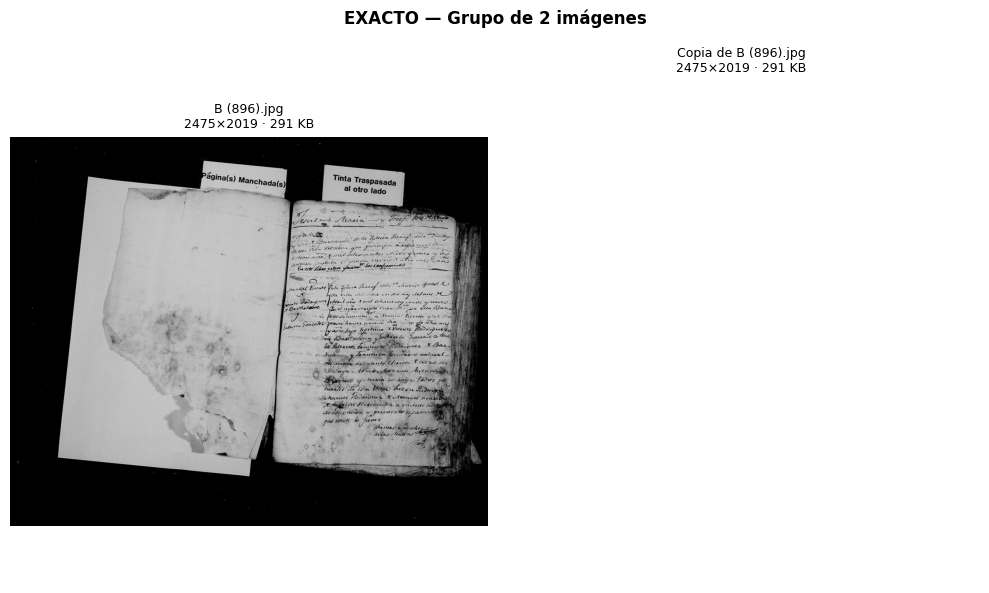

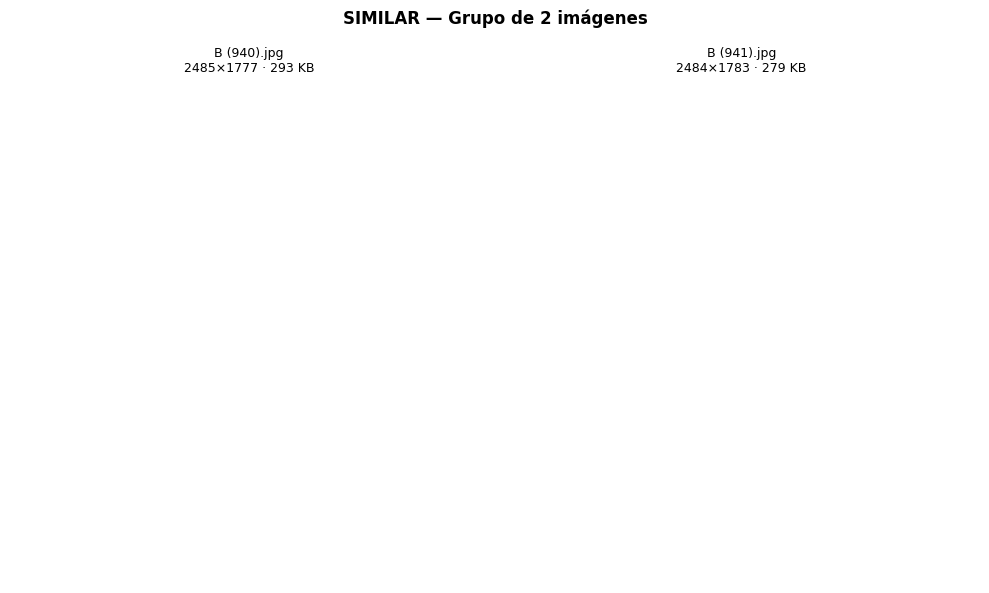

In [6]:
print(f"DEBUG: grupos_exactos tiene {len(grupos_exactos)} grupos")
print(f"DEBUG: grupos_similares tiene {len(grupos_similares)} grupos")
todos_los_grupos = [(g, 'EXACTO') for g in grupos_exactos] + \
                   [(g, 'SIMILAR') for g in grupos_similares]
print(f"DEBUG: todos_los_grupos tiene {len(todos_los_grupos)} elementos")

if not todos_los_grupos:
    print('No hay duplicados que mostrar.')
else:
    for grupo, tipo in todos_los_grupos:
        n = len(grupo)
        fig, axes = plt.subplots(1, n, figsize=(n * 5, 6))
        if n == 1:
            axes = [axes]

        for ax, ruta in zip(axes, grupo):
            img = cv2.imread(ruta)
            if img is not None:
                ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            d = info_archivos[ruta]
            ax.set_title(f'{d["nombre"]}\n{d["dims"]} · {d["tamaño_kb"]} KB', fontsize=9)
            ax.axis('off')

        fig.suptitle(f'{tipo} — Grupo de {n} imágenes', fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()

### Eliminar o mover duplicados

Conserva **siempre la imagen de mayor resolución** del grupo. Las demás se mueven a `imagenes_duplicadas/` (o se eliminan si cambias `MOVER_EN_VEZ_DE_ELIMINAR = False`).

In [ ]:
# Confirmación de seguridad — cambia a True para ejecutar
CONFIRMAR_ELIMINACION = True

if not CONFIRMAR_ELIMINACION:
    print('Simulación (sin cambios reales).')
    print('   Revisa el informe de arriba y pon CONFIRMAR_ELIMINACION = True para aplicar.')
    print()

eliminados = []
conservados = []

if MOVER_EN_VEZ_DE_ELIMINAR:
    Path(CARPETA_DUPLICADOS).mkdir(parents=True, exist_ok=True)

for grupo, tipo in todos_los_grupos:
    if not grupo:
        continue

    # Criterio de conservación: mayor número de píxeles (resolución)
    def resolucion(ruta):
        img = cv2.imread(ruta)
        return img.shape[0] * img.shape[1] if img is not None else 0

    grupo_ordenado = sorted(grupo, key=resolucion, reverse=True)
    a_conservar = grupo_ordenado[0]
    a_eliminar  = grupo_ordenado[1:]

    conservados.append(a_conservar)
    eliminados.extend(a_eliminar)

    print(f'{tipo}')
    print(f'    Conservar : {os.path.basename(a_conservar)} ({resolucion(a_conservar):,} px)')
    for r in a_eliminar:
        accion = 'Mover' if MOVER_EN_VEZ_DE_ELIMINAR else 'Eliminar'
        print(f'   {" " if MOVER_EN_VEZ_DE_ELIMINAR else "🗑️"} {accion}  : {os.path.basename(r)} ({resolucion(r):,} px)')
        if CONFIRMAR_ELIMINACION:
            if MOVER_EN_VEZ_DE_ELIMINAR:
                shutil.move(r, os.path.join(CARPETA_DUPLICADOS, os.path.basename(r)))
            else:
                os.remove(r)
    print()

accion_str = 'movidas' if MOVER_EN_VEZ_DE_ELIMINAR else 'eliminadas'
if CONFIRMAR_ELIMINACION:
    print(f' {len(eliminados)} imagen(es) {accion_str}.')
    print(f'   {len(conservados)} imagen(es) conservadas.')
    if MOVER_EN_VEZ_DE_ELIMINAR:
        print(f'   Duplicados en: {CARPETA_DUPLICADOS}')
else:
    print(f'Simulación completada: {len(eliminados)} imagen(es) se {accion_str}ían.')
    print('   Pon CONFIRMAR_ELIMINACION = True para aplicar los cambios.')

🔴 EXACTO
    Conservar : B (656) (1).jpg (4,804,936 px)
     Mover  : B (656).jpg (4,804,936 px)

🔴 EXACTO
    Conservar : B (658) (1).jpg (3,643,964 px)
     Mover  : B (658).jpg (3,643,964 px)

🔴 EXACTO
    Conservar : B (659) (1).jpg (4,496,604 px)
     Mover  : B (659).jpg (4,496,604 px)

🔴 EXACTO
    Conservar : B (662) (1).jpg (4,267,962 px)
     Mover  : B (662).jpg (4,267,962 px)

🔴 EXACTO
    Conservar : B (665) (1).jpg (4,663,916 px)
     Mover  : B (665).jpg (4,663,916 px)

🔴 EXACTO
    Conservar : B (666) (1).jpg (4,136,092 px)
     Mover  : B (666).jpg (4,136,092 px)

🔴 EXACTO
    Conservar : B (667) (1).jpg (3,750,956 px)
     Mover  : B (667).jpg (3,750,956 px)

🔴 EXACTO
    Conservar : B (668) (1).jpg (4,434,744 px)
     Mover  : B (668).jpg (4,434,744 px)

🔴 EXACTO
    Conservar : B (669) (1).jpg (4,016,992 px)
     Mover  : B (669).jpg (4,016,992 px)

 9 imagen(es) movidas.
   9 imagen(es) conservadas.
   Duplicados en: imagenes_duplicadas/
